# MDR-TS v11.3  
**Temporal-Station Soil Moisture Model + Rain Residual Correction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR  
**Notebook Type:** Training, Evaluation, Residual Modeling  
**Last Updated:** Tue Jan 6th 2026  

---

## Model Summary

- **Model Name:** MDR-TS  
- **Version:** v11.3  
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

This notebook implements a structured two-stage approach:

1. **Base Soil Model**  
   Trained using the best selected temporal and satellite-derived features.

2. **Rain-Based Residual Correction (Planned)**  
   Residuals from the base soil model will be modeled separately using rain-memory features to better capture recharge dynamics and rainfall-driven regime shifts.

The objective is controlled margin gains through decomposition of storage dynamics (soil) and forcing dynamics (rain).

---

## Reproducibility

- **Random Seed:** 42  
- **Split Metadata:** `data/splits/base/split_meta.json`  
- **Environment:** MacBook M2 Pro (local kernel)  

---

## What’s New

- Clean base soil model using selected feature subset  
- Explicit separation between:
  - Storage modeling (soil moisture dynamics)
  - Forcing modeling (rain memory dynamics)  
- Preparation for residual-based rain correction  

---

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

print("imports loaded")

plt.rcParams["figure.dpi"] = 120
np.random.seed(0)

imports loaded


## 1. Environment Setup

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 2.1.2
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [3]:
# Project paths
VERSION = "v11"
SUBVERSION = "v11.2"
RUN_NAME = "mdr_ts_v11_2"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v11/v11.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_new/train_derived_new.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_new/val_derived_new.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_new/test_derived_new.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

DROP_COLS = ["slope", "elev"]

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    cols_present = [c for c in DROP_COLS if c in d.columns]
    d.drop(columns=cols_present, inplace=True)
    print(f"{name}: dropped columns {cols_present}")
    print(f"\n{name}: shape={d.shape}")
    print(f"{name}: columns={len(d.columns)}")

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/train_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/val_derived_new.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_new/test_derived_new.csv
train: dropped columns ['slope', 'elev']

train: shape=(16972, 354)
train: columns=354
val: dropped columns ['slope', 'elev']

val: shape=(2919, 354)
val: columns=354
test: dropped columns ['slope', 'elev']

test: shape=(2829, 354)
test: columns=354


In [6]:
# Dropping TouchNet because it has no rows in the validation split

DROP_STATION = "Touchet_WA_824"

def drop_station(df, station_id=DROP_STATION):
    before = len(df)
    out = df[df["station_id"] != station_id].copy()
    after = len(out)
    print(f"Dropped {station_id}: {before} -> {after} rows (-{before-after})")
    return out

train_df = drop_station(train_df)
val_df   = drop_station(val_df)
test_df  = drop_station(test_df)

Dropped Touchet_WA_824: 16972 -> 13661 rows (-3311)
Dropped Touchet_WA_824: 2919 -> 2919 rows (-0)
Dropped Touchet_WA_824: 2829 -> 2659 rows (-170)


In [7]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 354

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'aspect', 'DOY', 'soil_moisture_5cm', 'D_sin_DOY', 'D_cos_DOY', 'F_NDVI', 'F_NDMI', 'F_MSI', 'E_SAR_ratio', 'E_SAR_diff', 'G_API', 'G_DSLR', 'G_rain_sum_3d', 'G_rain_sum_7d', 'G_rain_sum_30d', 'A_d_G_API_kobs1', 'A_d_G_API_kobs2', 'A_d_G_API_kobs5']


## 4. Data Sanity Checks

In [8]:
TARGET_COL = "soil_moisture_5cm"
KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS_ALL = [
  "precip_mm",
  "G_rain_sum_3d","G_rain_sum_7d","G_rain_sum_30d","G_API","G_DSLR",
  "C_lag_E_SAR_diff_kobs12","C_lag_E_SAR_diff_kobs30","C_lag_E_SAR_ratio_kobs30",
  "C_lag_F_NDVI_kobs30","C_lag_LST_modis_kobs12","C_lag_LST_modis_kobs30",
  "DOY","D_sa_E_SAR_ratio","D_sa_F_NDMI","D_z_E_SAR_ratio","D_z_F_NDMI",
  "E_SAR_diff","E_SAR_ratio","F_MSI","F_NDMI","V_ema_LST_modis_kobs30",
  "V_rollmax_E_SAR_diff_kobs14","V_rollmax_E_SAR_diff_kobs30","V_rollmax_F_NDVI_kobs30",
  "V_rollmax_G_API_kobs30","V_rollmax_G_API_kobs7","V_rollmax_LST_modis_kobs7",
  "V_rollmax_s2_b11_kobs30","V_rollmean_G_API_kobs30","V_rollmin_E_SAR_diff_kobs30",
  "V_rollmin_E_SAR_ratio_kobs30","V_rollmin_F_NDMI_kobs30","V_rollmin_G_API_kobs7",
  "V_rollmin_s2_b11_kobs30","V_rollmin_s2_b12_kobs30","s1_vh","s2_b8",
  "A_d_LST_modis_kobs7","A_grad_LST_modis_kobs14","C_lag_E_SAR_diff_kobs6",
  "V_rollmax_E_SAR_diff_kobs7","V_rollmax_E_SAR_ratio_kobs14","V_rollmax_F_NDVI_kobs14",
  "s2_b12","D_sa_LST_modis"
]

RAIN_FEATURE_COLS = [
    "G_rain_sum_3d",
    "G_API",
    "C_lag_G_API_kobs1",
    "G_rain_sum_7d",
    "A_grad_G_API_kobs7",
    "G_DSLR",
    "G_rain_sum_30d",
]

RAIN_FEATURE_COLS = [c for c in RAIN_FEATURE_COLS if c in train_df.columns]

BASE_SOIL_FEATURE_COLS = [
    c for c in FEATURE_COLS_ALL
    if (c not in RAIN_FEATURE_COLS) and (not c.startswith("G_")) and (c != "precip_mm")
]

print("Base soil features:", len(BASE_SOIL_FEATURE_COLS))
print("Rain residual features:", len(RAIN_FEATURE_COLS))

Base soil features: 40
Rain residual features: 7


In [9]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap

[INFO] No temporal leakage detected.


In [10]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [11]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     13661
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2659
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [12]:
y_train = train_df[TARGET_COL].astype(float).to_numpy()
y_val   = val_df[TARGET_COL].astype(float).to_numpy()
y_test  = test_df[TARGET_COL].astype(float).to_numpy()

X_train_base = train_df[BASE_SOIL_FEATURE_COLS].copy()
X_val_base   = val_df[BASE_SOIL_FEATURE_COLS].copy()
X_test_base  = test_df[BASE_SOIL_FEATURE_COLS].copy()

X_train_rain = train_df[RAIN_FEATURE_COLS].copy()
X_val_rain   = val_df[RAIN_FEATURE_COLS].copy()
X_test_rain  = test_df[RAIN_FEATURE_COLS].copy()

print("Feature matrix shapes:")
print(f"  Base X_train: {X_train_base.shape}   Rain X_train: {X_train_rain.shape}")
print(f"  Base X_val:   {X_val_base.shape}     Rain X_val:   {X_val_rain.shape}")
print(f"  Base X_test:  {X_test_base.shape}    Rain X_test:  {X_test_rain.shape}")
print(f"  y_train:      {y_train.shape}  y_val: {y_val.shape}  y_test: {y_test.shape}")

Feature matrix shapes:
  Base X_train: (13661, 40)   Rain X_train: (13661, 7)
  Base X_val:   (2919, 40)     Rain X_val:   (2919, 7)
  Base X_test:  (2659, 40)    Rain X_test:  (2659, 7)
  y_train:      (13661,)  y_val: (2919,)  y_test: (2659,)


### 6.2 Feature Overview

In [15]:
feature_summary_base = pd.DataFrame({
    "mean": X_train_base.mean(),
    "std": X_train_base.std(),
    "min": X_train_base.min(),
    "max": X_train_base.max(),
}).sort_values("std", ascending=False)

feature_summary_base

,mean,std,min,max
DOY,186.114267,101.996473,1.000000,366.000000
V_rollmax_G_API_kobs30,80.897382,78.128117,0.225530,408.757381
V_rollmax_G_API_kobs7,58.649375,64.478321,0.022210,408.757381
V_rollmean_G_API_kobs30,47.156096,49.766931,0.075323,313.507425
V_rollmin_G_API_kobs7,36.395941,44.245670,0.000000,337.178315
C_lag_LST_modis_kobs12,288.551497,11.380461,248.913937,316.363128
C_lag_LST_modis_kobs30,288.494421,11.376746,248.913937,316.363128
V_rollmax_LST_modis_kobs7,289.746537,11.105693,248.913937,316.363128
V_ema_LST_modis_kobs30,288.543790,10.615141,259.512757,312.940447
D_sa_LST_modis,0.890944,5.282230,-23.296544,19.291896


In [16]:
feature_summary_rain = pd.DataFrame({
    "mean": X_train_rain.mean(),
    "std": X_train_rain.std(),
    "min": X_train_rain.min(),
    "max": X_train_rain.max(),
}).sort_values("std", ascending=False)

feature_summary_rain

,mean,std,min,max
G_rain_sum_30d,141.161408,158.505265,0.000000,1100.500000
C_lag_G_API_kobs1,46.983869,54.991098,0.000000,408.757381
G_API,46.985479,54.988804,0.000000,408.757381
G_rain_sum_7d,37.330378,52.907762,0.000000,477.000000
G_rain_sum_3d,18.783969,30.828038,0.000000,259.400000
G_DSLR,3.356369,6.948153,0.000000,84.000000
A_grad_G_API_kobs7,0.014515,4.440098,-25.222883,34.970810


### 6.3 Feature Correlation

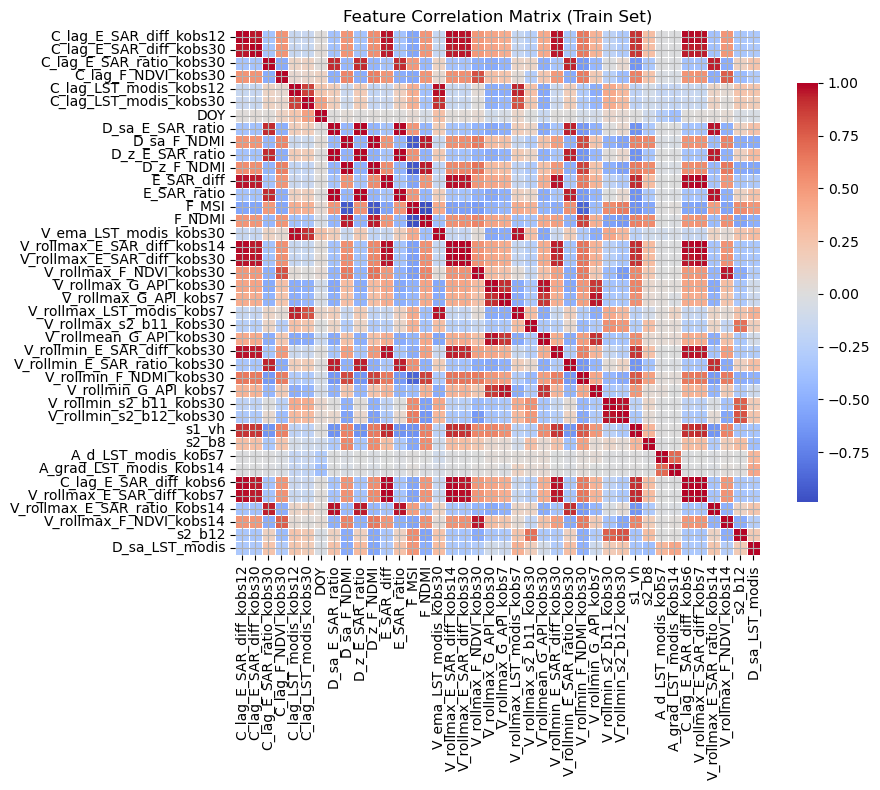

In [17]:
corr = X_train_base.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

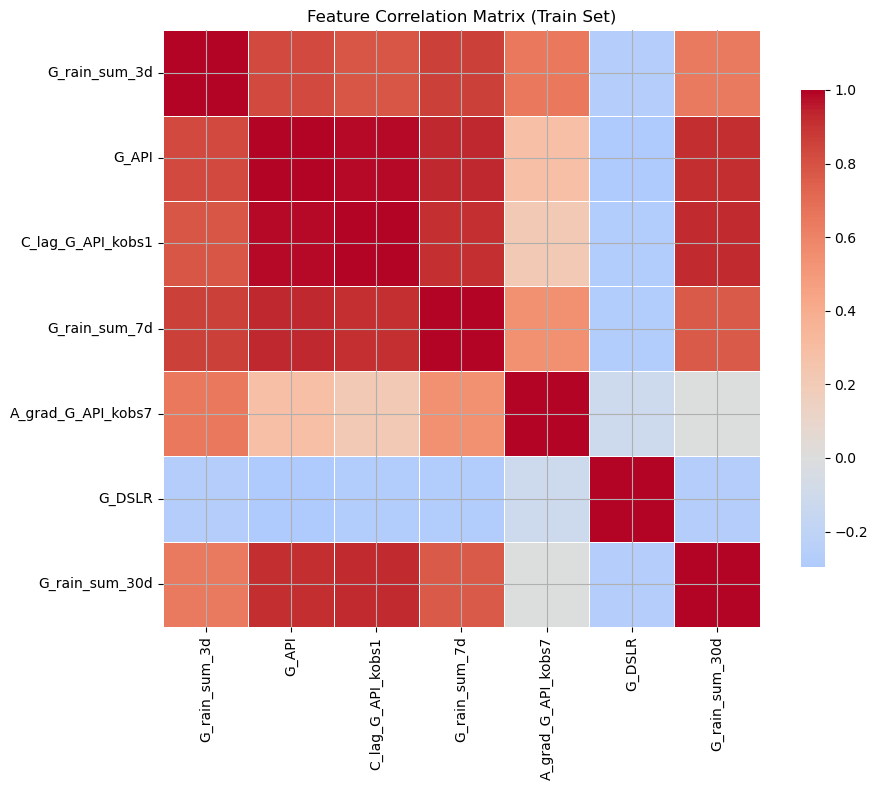

In [18]:
corr = X_train_rain.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix (Train Set)")
plt.tight_layout()
plt.show()

### 6.4 Baseline Model Definition

In [20]:
MODEL_CONFIG_SOIL_BASE = {
    "n_estimators": 8000,
    "learning_rate": 0.01,
    "max_depth": 6,
    "min_child_weight": 5,
    "gamma": 0.2,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.05,
    "reg_lambda": 2.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
}

MODEL_CONFIG_RAIN_RESID = {
    "n_estimators": 6000,
    "learning_rate": 0.01,
    "max_depth": 3,
    "min_child_weight": 10,
    "gamma": 0.3,
    "subsample": 0.9,
    "colsample_bytree": 1.0,
    "reg_alpha": 0.1,
    "reg_lambda": 5.0,
    "objective": "reg:squarederror",
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
}

In [21]:
model_base = XGBRegressor(**MODEL_CONFIG_SOIL_BASE)
print(model_base)

model_rain = XGBRegressor(**MODEL_CONFIG_RAIN_RESID)
print(model_rain)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.2, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=5, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=8000, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_type

## 7. Training Loop

In [23]:
def report(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:>18} | R2={r2:.4f}  MAE={mae:.4f}  RMSE={rmse:.4f}")
    return r2, mae, rmse

### 7.1 Fit Model

In [26]:
model_base.fit(
    X_train_base, y_train,
    eval_set=[(X_val_base, y_val)],
    verbose=2000,
)

yhat_train_base = model_base.predict(X_train_base)
yhat_val_base   = model_base.predict(X_val_base)
yhat_test_base  = model_base.predict(X_test_base)

print("Base predictions generated")
print("  yhat_train_base:", yhat_train_base.shape)
print("  yhat_val_base:  ", yhat_val_base.shape)
print("  yhat_test_base: ", yhat_test_base.shape)

print("\nBase Soil Model:")
report("train (base)", y_train, yhat_train_base)
report("val (base)",   y_val,   yhat_val_base)
report("test (base)",  y_test,  yhat_test_base)

[0]	validation_0-rmse:0.10103
[1000]	validation_0-rmse:0.04637
[2000]	validation_0-rmse:0.04638
[3000]	validation_0-rmse:0.04639
[4000]	validation_0-rmse:0.04638
[5000]	validation_0-rmse:0.04638
[6000]	validation_0-rmse:0.04638
[7000]	validation_0-rmse:0.04637
[7999]	validation_0-rmse:0.04638
Base predictions generated
  yhat_train_base: (13661,)
  yhat_val_base:   (2919,)
  yhat_test_base:  (2659,)

Base Soil Model:
      train (base) | R2=0.8619  MAE=0.0296  RMSE=0.0381
        val (base) | R2=0.7880  MAE=0.0350  RMSE=0.0464
       test (base) | R2=0.7231  MAE=0.0390  RMSE=0.0506


(0.72307165366705, 0.03900484189683667, 0.050553049134118726)

In [27]:
res_train = y_train - yhat_train_base
res_val   = y_val   - yhat_val_base

print("\nResiduals:")
print("  res_train mean/std:", float(np.mean(res_train)), float(np.std(res_train)))
print("  res_val   mean/std:", float(np.mean(res_val)),   float(np.std(res_val)))


Residuals:
  res_train mean/std: -1.037000621118172e-05 0.03814294271027162
  res_val   mean/std: 0.018359509245995668 0.042586942385291586


In [28]:
model_rain.fit(
    X_train_rain, res_train,
    eval_set=[(X_val_rain, res_val)],
    verbose=2000,
)

res_hat_train = model_rain.predict(X_train_rain)
res_hat_val   = model_rain.predict(X_val_rain)
res_hat_test  = model_rain.predict(X_test_rain)

print("\nResidual predictions generated")
print("  res_hat_train:", res_hat_train.shape)
print("  res_hat_val:  ", res_hat_val.shape)
print("  res_hat_test: ", res_hat_test.shape)

print("\nResidual Model:")
report("train (resid)", res_train, res_hat_train)
report("val (resid)",   res_val,   res_hat_val)

[0]	validation_0-rmse:0.04635
[2000]	validation_0-rmse:0.04497
[4000]	validation_0-rmse:0.04497
[5999]	validation_0-rmse:0.04496

Residual predictions generated
  res_hat_train: (13661,)
  res_hat_val:   (2919,)
  res_hat_test:  (2659,)

Residual Model:
     train (resid) | R2=0.0850  MAE=0.0280  RMSE=0.0365
       val (resid) | R2=-0.1145  MAE=0.0336  RMSE=0.0450


(-0.11453258756579388, 0.03361401872291815, 0.044959642140018435)

In [29]:
yhat_train_final = yhat_train_base + res_hat_train
yhat_val_final   = yhat_val_base   + res_hat_val
yhat_test_final  = yhat_test_base  + res_hat_test

In [30]:
print("\nFinal Combined Model:")
report("train (final)", y_train, yhat_train_final)
report("val (final)",   y_val,   yhat_val_final)
report("test (final)",  y_test,  yhat_test_final)

print("\nTraining complete (2-stage residual correction)")


Final Combined Model:
     train (final) | R2=0.8736  MAE=0.0280  RMSE=0.0365
       val (final) | R2=0.8007  MAE=0.0336  RMSE=0.0450
      test (final) | R2=0.7377  MAE=0.0379  RMSE=0.0492

Training complete (2-stage residual correction)


### 7.2 Metrics

### 7.3 Diagnostics

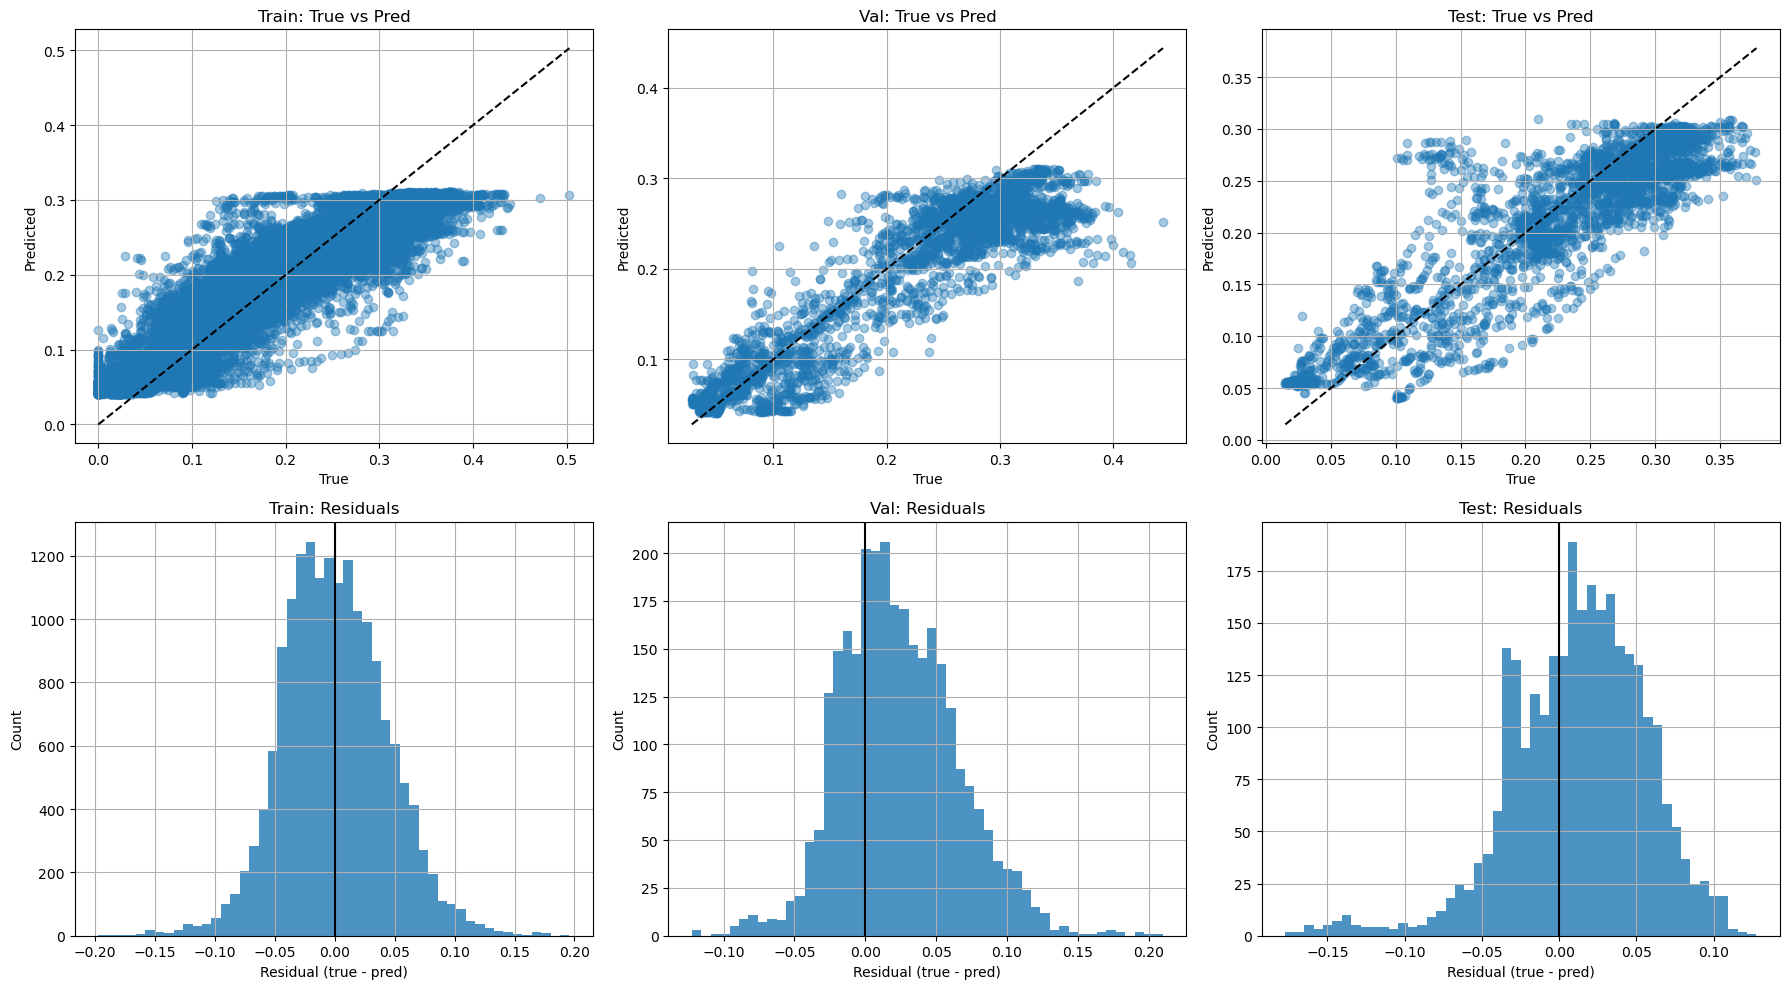

In [21]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test,  "Test: Residuals")

plt.tight_layout()
plt.show()

### 7.4 Feature Importance

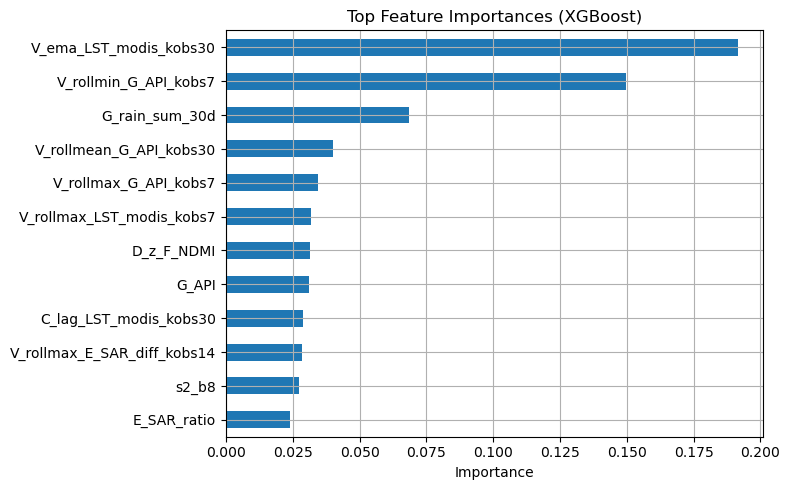

V_ema_LST_modis_kobs30          0.191431
V_rollmin_G_API_kobs7           0.149842
G_rain_sum_30d                  0.068562
V_rollmean_G_API_kobs30         0.040182
V_rollmax_G_API_kobs7           0.034561
V_rollmax_LST_modis_kobs7       0.031782
D_z_F_NDMI                      0.031409
G_API                           0.030980
C_lag_LST_modis_kobs30          0.028743
V_rollmax_E_SAR_diff_kobs14     0.028422
s2_b8                           0.027449
E_SAR_ratio                     0.023870
DOY                             0.020774
D_sa_F_NDMI                     0.020268
C_lag_E_SAR_diff_kobs6          0.019215
G_rain_sum_7d                   0.016874
V_rollmin_F_NDMI_kobs30         0.014065
V_rollmin_E_SAR_diff_kobs30     0.013975
G_DSLR                          0.012078
C_lag_LST_modis_kobs12          0.011601
V_rollmin_s2_b11_kobs30         0.011299
V_rollmax_G_API_kobs30          0.010314
G_rain_sum_3d                   0.010304
C_lag_E_SAR_diff_kobs12         0.010228
V_rollmin_E_SAR_

In [22]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [23]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test),
    "RMSE": rmse(y_test, yhat_test),
    "R2":   r2_score(y_test, yhat_test),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.036493,0.046039,0.757695,2829


### 8.2 Test Prediction Scatter

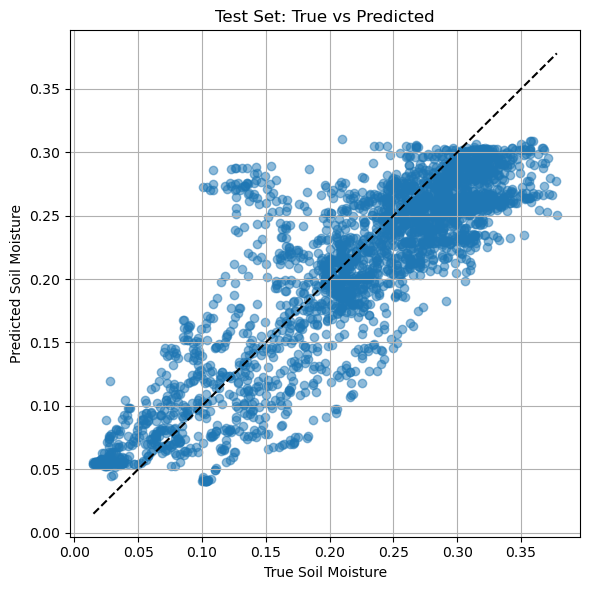

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [25]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val.min()): .6f} to {float(yhat_val.max()): .6f}
TEST range : {float(yhat_test.min()): .6f} to {float(yhat_test.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean :  0.023734
TEST residual mean :  0.012184

Prediction ranges
-----------------
VAL  range :  0.040858 to  0.310492
TEST range :  0.040858 to  0.310106



## 9. Metrics & Visalization

### 9.1 Generalization Gap

In [26]:
results_idx = results.set_index("split")

gap = {
    "train -> val (MAE)": float(results_idx.loc["val", "MAE"] - results_idx.loc["train", "MAE"]),
    "val -> test (MAE)":  float(results_idx.loc["test", "MAE"] - results_idx.loc["val", "MAE"]),
}
pd.DataFrame.from_dict(gap, orient="index", columns=["delta_MAE"])

,delta_MAE
train -> val (MAE),0.002299
val -> test (MAE),-0.000276


### 9.2 Feature Importance Recap

In [27]:
importances.head(10)

V_ema_LST_modis_kobs30         0.191431
V_rollmin_G_API_kobs7          0.149842
G_rain_sum_30d                 0.068562
V_rollmean_G_API_kobs30        0.040182
V_rollmax_G_API_kobs7          0.034561
V_rollmax_LST_modis_kobs7      0.031782
D_z_F_NDMI                     0.031409
G_API                          0.030980
C_lag_LST_modis_kobs30         0.028743
V_rollmax_E_SAR_diff_kobs14    0.028422
dtype: float32

## 10. Save Artifacts

In [28]:
from datetime import datetime

TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

RUN_DIR = os.path.join(OUTPUT_ROOT, f"{RUN_NAME}_{TIMESTAMP}")
os.makedirs(RUN_DIR, exist_ok=True)

print("Run directory:")
print(RUN_DIR)

Run directory:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260131_113814


In [29]:
MODEL_PATH = os.path.join(RUN_DIR, "model.json")
model.save_model(MODEL_PATH)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260131_113814/model.json


In [31]:
run_metadata = {
    "model_name": "MDR-TS",
    "version": "v1.0",
    "run_name": RUN_NAME,
    "timestamp": TIMESTAMP,
    "model_config": MODEL_CONFIG_FINAL,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "splits": {
        "train_stations": sorted(train_df["station_id"].unique().tolist()),
        "val_stations": sorted(val_df["station_id"].unique().tolist()),
        "test_stations": sorted(test_df["station_id"].unique().tolist()),
    },
    "data_sizes": {
        "train": len(train_df),
        "val": len(val_df),
        "test": len(test_df),
    },
}

META_PATH = os.path.join(RUN_DIR, "run_metadata.json")

with open(META_PATH, "w") as f:
    json.dump(run_metadata, f, indent=2)

print("Run metadata saved to:")
print(META_PATH)

Run metadata saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260131_113814/run_metadata.json


In [32]:
METRICS_PATH = os.path.join(RUN_DIR, "metrics.csv")
results.to_csv(METRICS_PATH)

print("Metrics saved to:")
print(METRICS_PATH)

Metrics saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260131_113814/metrics.csv


In [33]:
IMPORTANCE_PATH = os.path.join(RUN_DIR, "feature_importance.csv")
importances.to_csv(IMPORTANCE_PATH, header=["importance"])

print("Feature importance saved to:")
print(IMPORTANCE_PATH)

Feature importance saved to:
/Users/jbalkovec/Desktop/MDR//Models/Temporal/v7/v7.1/mdr_ts_v7_1_20260131_113814/feature_importance.csv


In [34]:
# save key figures
FIG_DIR = os.path.join(RUN_DIR, "figures")
# os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print("Saved:", path)

## SHAP Analysis

In [35]:
# might seem like bloat, but this is here to keep everything consistent
# + I can copy paste these cells to every other notebook

def _is_xgb(model):
    name = model.__class__.__name__.lower()
    return "xgb" in name or "xgboost" in name

def _is_rf(model):
    name = model.__class__.__name__.lower()
    return "randomforest" in name or "extratrees" in name

def _is_elasticnet(model):
    return model.__class__.__name__.lower() == "elasticnet"


def plot_heatmap(df, title):
    plt.figure(figsize=(12, 4 + 0.25 * len(df)))
    plt.imshow(df.values, aspect="auto")
    plt.yticks(range(len(df.index)), df.index)
    plt.xticks(range(len(df.columns)), df.columns, rotation=90)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [36]:
def shap_importance_block(
    models: dict,
    X_train: pd.DataFrame,
    X_eval: pd.DataFrame,
    background_size: int = 500,
    normalize: bool = True,
    top_k: int | None = 30,
    compute_corr: bool = True,
    random_state: int = 0,
):
    bg = X_train.sample(n=min(background_size, len(X_train)), random_state=random_state)

    rows = []
    for model_name, model in models.items():

        if _is_xgb(model) or _is_rf(model):
            explainer = shap.TreeExplainer(model)
        elif _is_elasticnet(model):
            explainer = shap.LinearExplainer(
                model, bg, feature_perturbation="interventional"
            )
        else:
            explainer = shap.Explainer(model.predict, bg)

        shap_values = explainer(X_eval)
        vals = shap_values.values

        if vals.ndim == 3:
            if vals.shape[1] == 2:
                vals = vals[:, 1, :]
            else:
                vals = vals.mean(axis=1)

        mean_abs = np.mean(np.abs(vals), axis=0)
        mean = np.mean(vals, axis=0)

        df = pd.DataFrame({
            "model": model_name,
            "feature": X_eval.columns,
            "mean_abs_shap": mean_abs,
            "mean_shap": mean,
        }).sort_values("mean_abs_shap", ascending=False)

        df["rank"] = np.arange(1, len(df) + 1)
        if top_k is not None:
            df = df.head(top_k)

        if normalize:
            s = df["mean_abs_shap"].sum()
            df["mean_abs_shap_norm"] = df["mean_abs_shap"] / (s if s != 0 else 1)

        rows.append(df)

    importance_long = pd.concat(rows, ignore_index=True)

    value_col = "mean_abs_shap_norm" if normalize else "mean_abs_shap"
    heatmap_wide = (
        importance_long
        .pivot_table(index="model", columns="feature", values=value_col, fill_value=0.0)
        .sort_index()
    )

    corr = X_eval.corr(method="spearman") if compute_corr else None

    return importance_long, heatmap_wide, corr

In [37]:
models = {
    "xgb": model,
    "rf": model_rf
}

In [38]:
importance_long, heatmap_wide, corr = shap_importance_block(
    models=models,
    X_train=X_train,
    X_eval=X_test,
    normalize=True,
    top_k=25,
    compute_corr=True,
)

PermutationExplainer explainer:  22%|██▏       | 621/2829 [11:35<41:57,  1.14s/it]  


KeyboardInterrupt: 

In [ ]:
importance_long.head(10)

In [ ]:
heatmap_wide

In [ ]:
plot_heatmap(
    heatmap_wide,
    title="Models x Features (normalized mean |SHAP|)"
)

In [ ]:
if corr is not None:
    plot_heatmap(
        corr,
        title="Feature correlation (Spearman)"
    )

In [ ]:
best_model = models["xgb"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
)

In [ ]:
best_model = models["rf"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
)

---

_Jakob Balkovec_